In [1]:
%load_ext autoreload
%autoreload 2


In [7]:
import sys
import os
#os.chdir("src")
#sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
sys.path.append(os.path.abspath('..'))
from src.tme3_corr import *
from src.tme2 import *

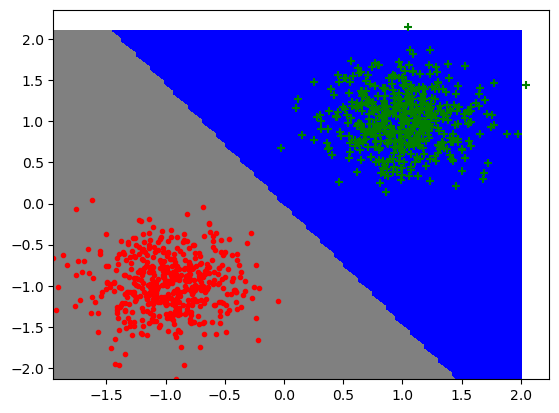

0/100  loss: 0.0, train: 1.0, test: 0
10/100  loss: 0.0, train: 1.0, test: 0
20/100  loss: 0.0, train: 1.0, test: 0
30/100  loss: 0.0, train: 1.0, test: 0
40/100  loss: 0.0, train: 1.0, test: 0
50/100  loss: 0.0, train: 1.0, test: 0
60/100  loss: 0.0, train: 1.0, test: 0
70/100  loss: 0.0, train: 1.0, test: 0
80/100  loss: 0.0, train: 1.0, test: 0
90/100  loss: 0.0, train: 1.0, test: 0


In [3]:
np.random.seed(42)
## Tirage d'un jeu de données aléatoire avec un bruit de 0.1
datax, datay = gen_arti(epsilon=0.1)
## Fabrication d'une grille de discrétisation pour la visualisation de la fonction de coût
grid, x_grid, y_grid = make_grid(xmin=-2, xmax=2, ymin=-2, ymax=2, step=100)

plt.figure()

## Visualisation des données et de la frontière de décision pour un vecteur de poids w
w  = np.random.randn(datax.shape[1],1)
plot_frontiere(datax,lambda x : np.sign(x.dot(w)),step=100)
plot_data(datax,datay)

plt.show()

perceptron = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01)
perceptron.fit(datax, datay)

0/100  loss: 2451.776529939079, train: 0.5442622950819672, test: 0.5151515151515151
10/100  loss: 327.01284234520864, train: 0.7114754098360656, test: 0.6636363636363637
20/100  loss: 105.95331886247803, train: 0.8122950819672131, test: 0.7878787878787878
30/100  loss: 57.269854740100676, train: 0.8852459016393442, test: 0.8666666666666667
40/100  loss: 39.21426378249227, train: 0.9155737704918033, test: 0.9030303030303031
50/100  loss: 29.543459343574003, train: 0.9368852459016394, test: 0.9121212121212121
60/100  loss: 23.628160233276585, train: 0.9442622950819672, test: 0.9272727272727272
70/100  loss: 19.088580993002225, train: 0.95, test: 0.9363636363636364
80/100  loss: 15.355355107116061, train: 0.9557377049180328, test: 0.9393939393939394
90/100  loss: 12.869373391967747, train: 0.9598360655737705, test: 0.9424242424242424


ValueError: cannot reshape array of size 33153 into shape (16,16)

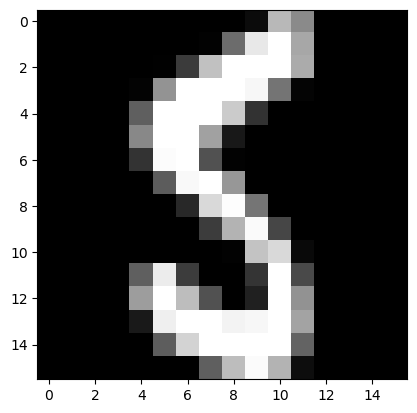

In [11]:
uspsdatatrain = "../data/USPS_train.txt"
uspsdatatest = "../data/USPS_test.txt"
alltrainx,alltrainy = load_usps(uspsdatatrain)
alltestx,alltesty = load_usps(uspsdatatest)
neg = 5
pos = 6
datax,datay = get_usps([neg,pos],alltrainx,alltrainy)
testx,testy = get_usps([neg,pos],alltestx,alltesty)
p = Lineaire(max_iter=100,eps=0.1, proj=proj_poly_gen)
p.fit(datax,datay,testx,testy)
plt.ion()
show_usps(datax[1,:])
show_usps(p.w)


0/100  loss: 0.25068016001376053, train: 0.485, test: 0
10/100  loss: 0.07503880805346054, train: 0.5175, test: 0
20/100  loss: 0.013197711957038297, train: 0.49875, test: 0
30/100  loss: 0.014350561916725927, train: 0.50125, test: 0
40/100  loss: 0.015259373307447078, train: 0.5025, test: 0
50/100  loss: 0.016012005378934813, train: 0.5025, test: 0
60/100  loss: 0.016742278204828466, train: 0.50125, test: 0
70/100  loss: 0.01738282045373982, train: 0.50125, test: 0
80/100  loss: 0.017999583299099897, train: 0.50125, test: 0
90/100  loss: 0.018583695954749336, train: 0.50125, test: 0
lineaire : train 0.503750, test 0.501250
0/100  loss: 0.5437170187441953, train: 0.5, test: 0
10/100  loss: 0.02403460158369535, train: 0.8625, test: 0
20/100  loss: 0.005646053520841301, train: 0.9525, test: 0
30/100  loss: 0.0028357596885710103, train: 0.96875, test: 0
40/100  loss: 0.001582894449707619, train: 0.97875, test: 0
50/100  loss: 0.0012356257795386146, train: 0.985, test: 0
60/100  loss: 0.00

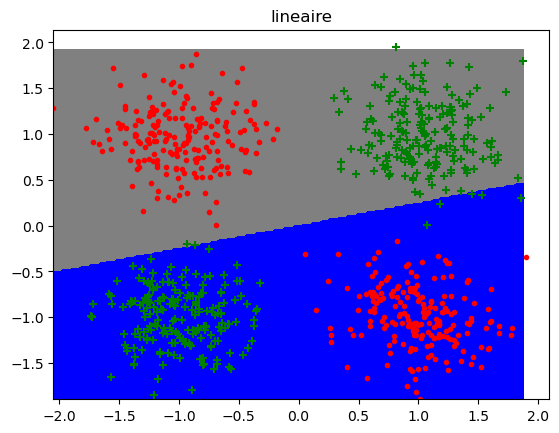

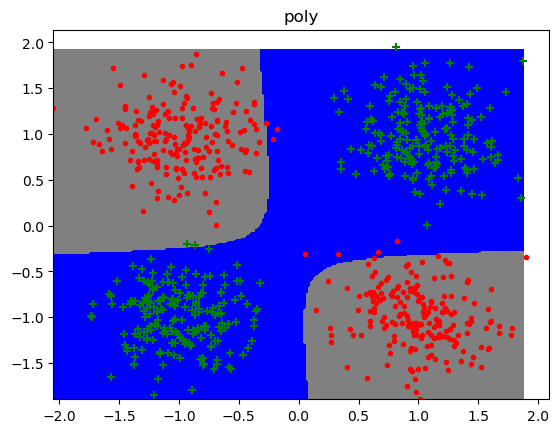

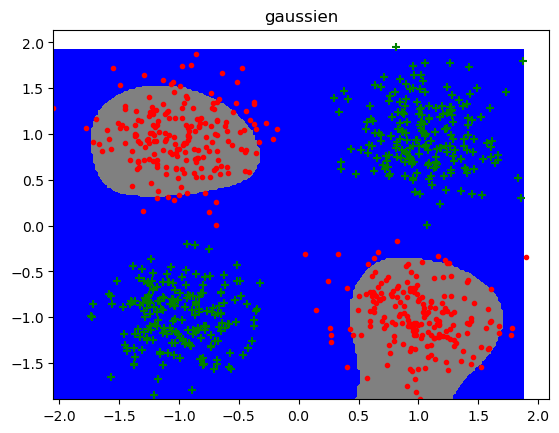

In [15]:
p.max_iter = 100
for i,dname in zip(range(3),["gauss", "XOR", "echiquier"]):
    if i!=1: continue
    trainx,trainy =gen_arti(nbex=800,data_type=i)
    testx,testy = gen_arti(nbex=800,data_type=i)
    for proj,pname in zip([None, proj_poly_gen, lambda x: proj_gauss(x,trainx[:500,:],sigma=0.5)],["lineaire","poly","gaussien"]):
        p.proj = proj
        p.fit(trainx,trainy)
        print("%s : train %f, test %f"% (pname,p.score(trainx,trainy),p.score(testx,testy)))
        plt.figure()
        plot_frontiere(trainx,p.predict,200)
        plot_data(trainx,trainy)
        plt.title("%s"  %(pname,))




In [ ]:
pg = proj_gauss(datax,base,sigma=1)

In [16]:
np.triu_indices(5)

(array([0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 4]),
 array([0, 1, 2, 3, 4, 1, 2, 3, 4, 2, 3, 4, 3, 4, 4]))